In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


Using device: cuda
GPU name: Tesla T4


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
import os

os.listdir("/content/drive/MyDrive")


['Week16_예습과제_안예은.ipynb',
 'Classroom',
 '제목없는 폴더',
 '2020 2학년 2기말 수학2_서술형채점기준표.pdf',
 '2020 2학년 기말 수학2 문항정보표.pdf',
 '2020 2기말 수학2 문제지.pdf',
 '2020학년도 2학기 기말고사 2학년 확률과통계 출제원안.pdf',
 '2020학년도 2학기 기말고사 2학년 확률과통계 서술형채점기준표.pdf',
 '2020학년도 2학기 기말고사 2학년 확률과통계 문항정보표.pdf',
 'Colab Notebooks',
 'Untitled0.ipynb',
 'Untitled1.ipynb',
 'Chap_4_Intro_to_Python (1).ipynb',
 'Markdown_Guide (1).ipynb',
 '통계수학_개강_전_과제 (1).ipynb',
 'Section_1_Matrix_LAB.ipynb',
 'Section_1_Matrix_HW (3).ipynb',
 'Sec_3_Linear_system_and_matrix_HW.ipynb',
 '제목 없는 설문지 (1).gform',
 '제목 없는 설문지.gform',
 'Sec_7_HW_Solution.ipynb',
 'IMG_1929.jpeg',
 'test (1).txt',
 'ArrayStack (1).h',
 '입학허가서_2229014_안예은_입증서류.pdf',
 '입학허가서.pdf',
 '수강예정교과목리스트_2229014_안예은_수강예정 (1).pdf',
 

In [5]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/archive.zip"
extract_path = "/content/archive"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted files:")
print(os.listdir(extract_path))



Extracted files:
['train', 'test']


In [6]:
for root, dirs, files in os.walk("/content/archive"):
    print(root)
    print("dirs:", dirs)
    print("files:", files)
    break


/content/archive
dirs: ['train', 'test']
files: []


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
from tqdm import tqdm
import time


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


Using device: cuda
GPU: Tesla T4


In [9]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [10]:
train_dataset = datasets.ImageFolder(
    root="/content/archive/train",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root="/content/archive/test",
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Classes:", train_dataset.classes)
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))


Classes: ['hot_dog', 'not_hot_dog']
Train size: 498
Val size: 500


In [11]:
model = models.resnet50(pretrained=True)
model.fc = nn.Linear(2048, 2)   # 이진 분류
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 134MB/s]


Total params: 23,512,130
Trainable params: 23,512,130


In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 100


In [13]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0, path="checkpoint.pt"):
        self.patience = patience
        self.delta = delta
        self.path = path
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = float("inf")

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss


In [14]:
def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for x, y in tqdm(loader):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return running_loss / len(loader), 100 * correct / total


In [15]:
def validate(model, loader):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in tqdm(loader):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            outputs = model(x)
            loss = criterion(outputs, y)

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return running_loss / len(loader), 100 * correct / total


In [16]:
early_stopping = EarlyStopping(patience=5)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

start_time = time.time()

for epoch in range(epochs):
    print(f"\nEpoch [{epoch+1}/{epochs}]")

    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = validate(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%")

    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("Early stopping triggered")
        break

end_time = time.time()
print(f"Training time: {(end_time - start_time)/60:.2f} minutes")



Epoch [1/100]


100%|██████████| 16/16 [00:03<00:00,  4.93it/s]


Train Loss: 0.6556 | Train Acc: 71.08%
Val   Loss: 20.9153 | Val   Acc: 38.00%

Epoch [2/100]


100%|██████████| 16/16 [00:02<00:00,  6.01it/s]


Train Loss: 0.5698 | Train Acc: 73.29%
Val   Loss: 0.9917 | Val   Acc: 57.00%

Epoch [3/100]


...

Train Loss: 0.3374 | Train Acc: 86.55%
Val   Loss: 1.1042 | Val   Acc: 63.40%
EarlyStopping counter: 3/5

Epoch [12/100]


100%|██████████| 16/16 [00:02<00:00,  6.83it/s]


Train Loss: 0.2140 | Train Acc: 91.57%
Val   Loss: 0.6565 | Val   Acc: 75.00%
EarlyStopping counter: 4/5

Epoch [13/100]


100%|██████████| 16/16 [00:02<00:00,  6.33it/s]

Train Loss: 0.1978 | Train Acc: 92.57%
Val   Loss: 0.7710 | Val   Acc: 79.40%
EarlyStopping counter: 5/5
Early stopping triggered
Training time: 1.77 minutes


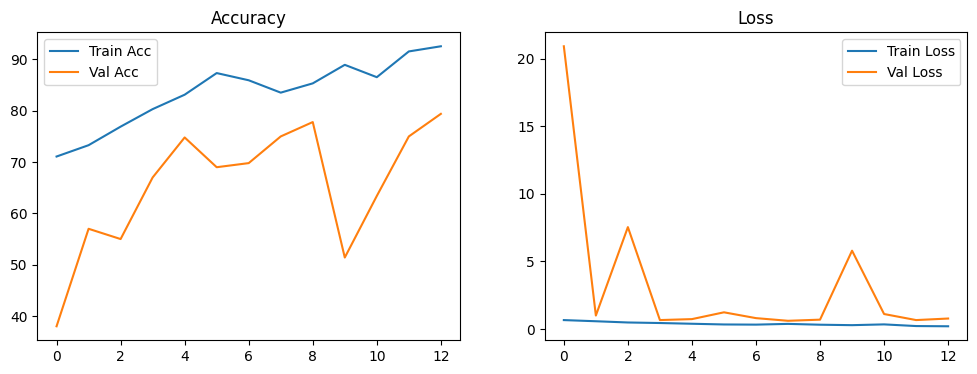

In [17]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss")

plt.show()


In [18]:
torch.save(model.state_dict(), "final_model.pth")
print("Model saved as final_model.pth")


Model saved as final_model.pth
